In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import cv2

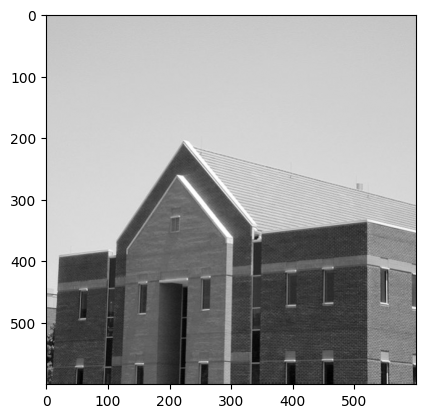

In [2]:
ruta = 'Copia de Casa con bordes.jpg'
imagen = cv2.imread(ruta, cv2.IMREAD_GRAYSCALE)
plt.imshow(imagen, cmap='gray')

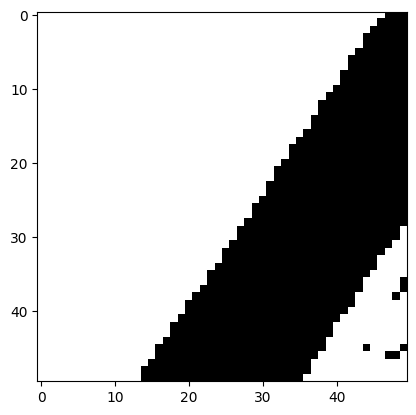

In [3]:
#. Debemos binarizar la imagen para aplicar las operaciones morfológicas. Para esto, podemos usar un umbral fijo o adaptativo. Aquí usaremos un umbral fijo.
_, imagen_binaria = cv2.threshold(imagen, 100, 255, cv2.THRESH_BINARY)
imagen_binaria = imagen_binaria[250:300, 150:200]

plt.imshow(imagen_binaria, cmap='gray')
plt.show()

# Morfología

En la biología la morfología habla acerca de la forma y estructura de los animales y plantas. Para el caso de mathematical morphology es una herramienta para extrar las componentes de la imagen que son útiles en la representación y descripción de la forma de la región, como los bordes, esqueletos (skeletons), y la envolvente convexa (convex full)

### Elemento estructurante

Debemos crear una matriz donde tengamos un elemento '"principal o central" y que corroboremos que al hacer una convolución todos los elementos del estructurante queden con lo que se agarre de la imagen.

In [4]:
# Normal de 3 x 3 
# Matriz normal
# EE = np.array([[0, 255, 0],
#                [255, 255, 255],
#                [0, 255, 0]], dtype=np.uint8)
EE = np.array([[255, 0, 255],
               [0, 0, 0],
               [255, 0, 255]], dtype=np.uint8)
# Escoger el centro de operaciones:
centro = (1, 1)


In [5]:
# Reflejado
# Matriz reflejada
EE_reflejada = np.zeros(EE.shape, dtype=np.uint8)
y, x = EE.shape
for j in range(y):
    for i in range(x):
        EE_reflejada[j][i] = EE[y - j - 1][x - i - 1]
print(EE_reflejada)
# Centro reflejado
centro_reflejado = (x - centro[0] - 1, y - centro[1] - 1)
print(centro_reflejado)



[[255   0 255]
 [  0   0   0]
 [255   0 255]]
(1, 1)


# Operaciones morfológicas básicas

## Dilatación y erosión
- Dilatación: engrosamiento de regiones.
- Erosión: adelgazamiento de regiones.

# Dilatación

Esta transformación mofológica combina dos conjuntos utilizando la adición de vectores (o adición de Minkoswski). La dilatación $X \oplus B$ es el conjunto de puntos de todas las posibles adiciones vectoriales de pares de elementos, uno de cada conjunto $X$ y $B$

- Dilatar las partículas es equivalente a erosionar el fondo.
- Elimina pequeños agujeros aislados en las partículas;

Definición matemática:
$$ A \oplus B = \{c | c = a + b \text{ para algún } a \in A \text{ y } b \in B \} $$


In [6]:
# Debemos aplicar el EE a toda la imagen, pero recordando el centro de este, así que pasamos por todo la 
## imagen y vemos si todos los elementos del EE coinciden con los elementos de la imagen, si es así, 
## el resultado es 1, sino es 0. Esto se hace para cada píxel de la imagen.
## Para esto, debemos recorrer la imagen desde el centro del EE hasta el final de la imagen, y
## desde el centro del EE hasta el inicio de la imagen, para evitar salirnos de los límites de la imagen, 
## se hace un padding del ancho y alto del EE.

#### Padding

In [7]:
def padding(imagen, dx, dy):
  y, x = imagen.shape
  paddineada = (np.zeros((int(y + dy/2 + 1), int(x + dx/2 + 1))) + 1) * 255
  for j in range(y):
    for i in range(x):
      paddineada[int(j + dy/4)][int(i + dx/4)] = imagen[j][i]
  return np.array(paddineada)

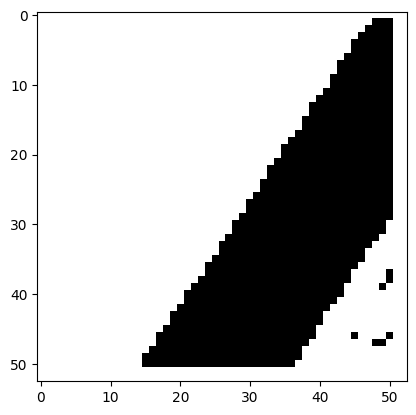

In [8]:
# Creamos la imagen padeada para aplicar las operaciones:
y, x = EE.shape
# Como el centro nos dice cuanto debemos padear, debemos saber cuanto a la izquierda y derecha
# esta el centro, con las coordenadas lo sabemos:
ima_padeada = padding(imagen_binaria, x + centro_reflejado[0], y + centro_reflejado[1])
plt.imshow(ima_padeada, cmap='gray')

In [9]:
# Inicializamos la matriz de resultado con el mismo tamaño de la imagen original
resultado = np.zeros(imagen_binaria.shape, dtype=np.uint8)
y_img, x_img = resultado.shape
y_ee, x_ee = EE_reflejada.shape

for j in range(y_img):
    for i in range(x_img):
        # 1. Extraemos la región de interés (ROI) de la imagen con padding.
        # El tamaño de la ROI debe ser exactamente el mismo tamaño que el EE.
        roi = ima_padeada[j : j + y_ee, i : i + x_ee]
        
        # 2. Comparamos con el EE reflejado mediante producto punto.
        # Para la dilatación, basta con que un solo píxel coincida (intersección > 0).
        interseccion = np.sum(roi * EE_reflejada)
        
        if interseccion > 255 * 5:
            resultado[j][i] = 255
            # print(f'El píxel ({i}, {j}) es 1') # Puedes descomentar para depurar
        else:
            resultado[j][i] = 0

# Aseguramos el tipo de dato correcto para la visualización
resultado = resultado.astype(np.uint8)


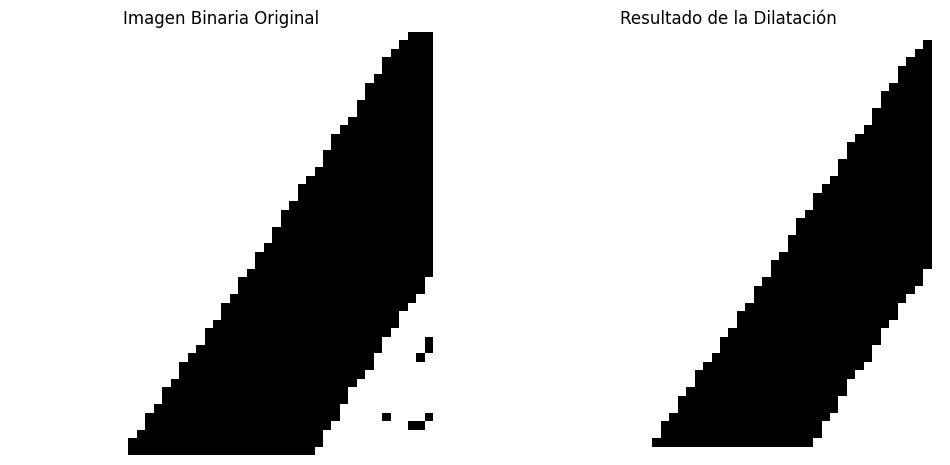

In [10]:
# Mostrar el resultado de la dilatación con la imagen original para comparar
figure, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(imagen_binaria, cmap='gray')
axes[0].set_title('Imagen Binaria Original')
axes[0].axis('off')

axes[1].imshow(resultado, cmap='gray')
axes[1].set_title('Resultado de la Dilatación')
axes[1].axis('off')
plt.show()

## Erosion

Elimina los píceles aislados en el fondo y erosiona (reduce) el contrno de las partículas con respecto al patrón definido por el SE
$$ A - B \{x | (B)_x \subset A\} $$

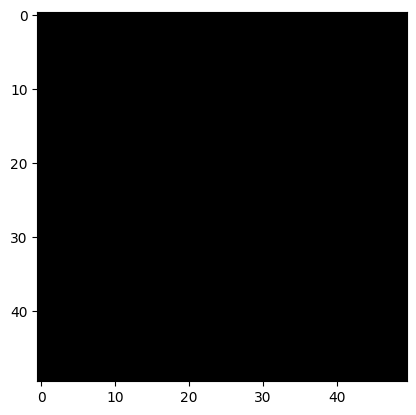

In [11]:
# Pasamos por toda la imagen padeada y aplicamos el EE:
## Creamos la imagen resultado:
resultado = np.zeros(imagen_binaria.shape, dtype=np.uint8)
y_pad, x_pad = resultado.shape
EE_cuadrada = np.sum(EE_reflejada * EE_reflejada)
for j in range(y_pad):
    for i in range(x_pad):
        # Aplicamos el EE en la posición (i, j):
        # Extraemos la región de interés:
        roi = ima_padeada[ j : j + y, i : i + x ]
        # Comparamos con el EE reflejado:
        ## Sumamos el producto punto de roi con EE y vemos si es igual a EE al cuadrado:
        if np.sum(roi * EE_reflejada) == EE_cuadrada:
            resultado[j][i] = 255
            print(f'El píxel ({i}, {j}) es 1')
        else:
            resultado[j][i] = 0

resultado = resultado.astype(np.uint8)

plt.imshow(resultado, cmap='gray')
plt.show()

## Apertura (opening)
Erosion + Dilatación

$$ A \circ B = (A - B) + B $$

- Remosion de pequenas particulas y suaviza los bordes
- No altera el tamano de las paríticulas
- Las peuquenas particulas desaparecen durante la erosion no vuelven a apartecer despues de la dilatación

## Cierre (closing)
Dilatacion + Erosion



